In [ ]:
import h5py
with h5py.File("./data/baryons_logPkR.h5", 'r') as f:
    print(f.keys())
    print(f['antilles'].keys())

In [1]:
import numpy as np
import scipy

nsrcs = 5
nlens = 10
ntheta = 20
ndv = int((nsrcs*(nsrcs+1)/2+nsrcs*nlens+nlens)*ntheta)

baseline  = np.loadtxt('./chains/lsst_baseline_evaluate/lsst.modelvector')[:,1]
pollution = np.loadtxt('./chains/lsst_pollution_evaluate/lsst.modelvector')[:,1]
print(f'len of baseline {len(baseline)}; len of polution {len(pollution)}; expected ndv {ndv}')

cov_raw = np.loadtxt('./data/cov_lsst_fourier')
cov = np.zeros((ndv,ndv))
for i in range(len(cov_raw)):
    ii,jj = int(cov_raw[i,0]),int(cov_raw[i,1])
    component = cov_raw[i,8]+cov_raw[i,9]
    cov[ii,jj] = component
    cov[jj,ii] = component

#mask = np.ones(ndv)
mask_shear_full = np.loadtxt('./data/lsst_full_shear_DESY3_lens_fourier.mask')[:,1]
tol = 1/10

def probechi2(start,end,probe):
    delta = (pollution - baseline)[start:end]
    mask = mask_shear_full[start:end].astype(bool)
    delta_masked = delta[mask]
    cov_delta = cov[start:end,:][:,start:end]
    cov_delta_masked = cov_delta[mask,:][:,mask]
    invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
    chi2 = delta_masked@invcov_delta_masked@delta_masked
    print(f'chi2 of probe {probe} is {chi2}')
    print(f'{np.sum(mask)}/{len(mask)} points remain for probe {probe}')

ncombo0=0
cnt = 0
for ni in range(nsrcs):
    for nj in range(ni, nsrcs):
        delta = (pollution - baseline)[cnt*ntheta:(cnt+1)*ntheta]
        mask = mask_shear_full[cnt*ntheta:(cnt+1)*ntheta].astype(bool)
        delta_masked = delta[mask]
        cov_delta = cov[cnt*ntheta:(cnt+1)*ntheta,:][:,cnt*ntheta:(cnt+1)*ntheta]
        cov_delta_masked = cov_delta[mask,:][:,mask]
        invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
        chi2 = delta_masked@invcov_delta_masked@delta_masked
        idx_mask=1
        while(chi2>tol and idx_mask<=ntheta):
            mask_shear_full[(cnt+1)*ntheta-idx_mask] = 0
            mask = mask_shear_full[cnt*ntheta:(cnt+1)*ntheta].astype(bool)
            delta_masked = delta[mask]
            cov_delta = cov[cnt*ntheta:(cnt+1)*ntheta,:][:,cnt*ntheta:(cnt+1)*ntheta]
            cov_delta_masked = cov_delta[mask,:][:,mask]
            invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
            chi2 = delta_masked@invcov_delta_masked@delta_masked
            idx_mask+=1
        print(f'C_ss ni={ni}, nj={nj}, chi2={chi2:.2e}')
        cnt+=1
ncombo2=cnt
probechi2(ncombo0*ntheta, ncombo2*ntheta,'C_ss')
for ni in range(nlens):
    for nj in range(nsrcs):
        delta = (pollution - baseline)[cnt*ntheta:(cnt+1)*ntheta]
        mask = mask_shear_full[cnt*ntheta:(cnt+1)*ntheta].astype(bool)
        delta_masked = delta[mask]
        cov_delta = cov[cnt*ntheta:(cnt+1)*ntheta,:][:,cnt*ntheta:(cnt+1)*ntheta]
        cov_delta_masked = cov_delta[mask,:][:,mask]
        invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
        chi2 = delta_masked@invcov_delta_masked@delta_masked
        print(f'C_gs ni={ni}, nj={nj}, chi2={chi2:.2e}')
        cnt+=1
ncombo3=cnt
probechi2(ncombo2*ntheta, ncombo3*ntheta,'C_gs')
for ni in range(nlens):
        delta = (pollution - baseline)[cnt*ntheta:(cnt+1)*ntheta]
        mask = mask_shear_full[cnt*ntheta:(cnt+1)*ntheta].astype(bool)
        delta_masked = delta[mask]
        cov_delta = cov[cnt*ntheta:(cnt+1)*ntheta,:][:,cnt*ntheta:(cnt+1)*ntheta]
        cov_delta_masked = cov_delta[mask,:][:,mask]
        invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
        chi2 = delta_masked@invcov_delta_masked@delta_masked
        print(f'C_gg ni={ni}, nj={ni}, chi2={chi2:.2e}')
        cnt+=1
ncombo4=cnt
probechi2(ncombo3*ntheta, ncombo4*ntheta,'C_gg')

len of baseline 1500; len of polution 1500; expected ndv 1500
C_ss ni=0, nj=0, chi2=5.75e-02
C_ss ni=0, nj=1, chi2=5.47e-02
C_ss ni=0, nj=2, chi2=9.11e-02
C_ss ni=0, nj=3, chi2=6.16e-02
C_ss ni=0, nj=4, chi2=9.58e-02
C_ss ni=1, nj=1, chi2=8.93e-02
C_ss ni=1, nj=2, chi2=7.63e-02
C_ss ni=1, nj=3, chi2=5.57e-02
C_ss ni=1, nj=4, chi2=9.84e-02
C_ss ni=2, nj=2, chi2=4.70e-02
C_ss ni=2, nj=3, chi2=3.80e-02
C_ss ni=2, nj=4, chi2=6.90e-02
C_ss ni=3, nj=3, chi2=6.31e-02
C_ss ni=3, nj=4, chi2=4.52e-02
C_ss ni=4, nj=4, chi2=6.45e-02
chi2 of probe C_ss is 0.25735152914621867
80/300 points remain for probe C_ss
C_gs ni=0, nj=0, chi2=1.40e-02
C_gs ni=0, nj=1, chi2=7.34e-02
C_gs ni=0, nj=2, chi2=6.73e-02
C_gs ni=0, nj=3, chi2=5.29e-02
C_gs ni=0, nj=4, chi2=3.57e-02
C_gs ni=1, nj=0, chi2=4.27e-04
C_gs ni=1, nj=1, chi2=4.87e-02
C_gs ni=1, nj=2, chi2=6.38e-02
C_gs ni=1, nj=3, chi2=5.68e-02
C_gs ni=1, nj=4, chi2=4.14e-02
C_gs ni=2, nj=0, chi2=1.09e-04
C_gs ni=2, nj=1, chi2=1.82e-02
C_gs ni=2, nj=2, chi2=5

In [2]:
nlen = len(mask_shear_full)
out = np.zeros((nlen,2))
out[:,0] = np.arange(nlen)
out[:,1] = mask_shear_full
print(f'check the number {np.sum(mask_shear_full)}/{len(mask_shear_full)} for this mask')
np.savetxt('./data/lsst_Y3.mask', out)

check the number 652.0/1500 for this mask


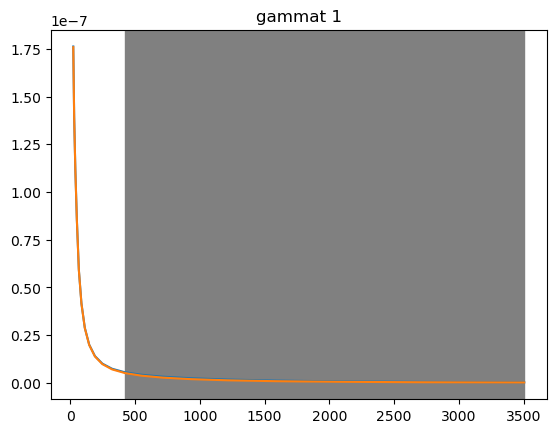

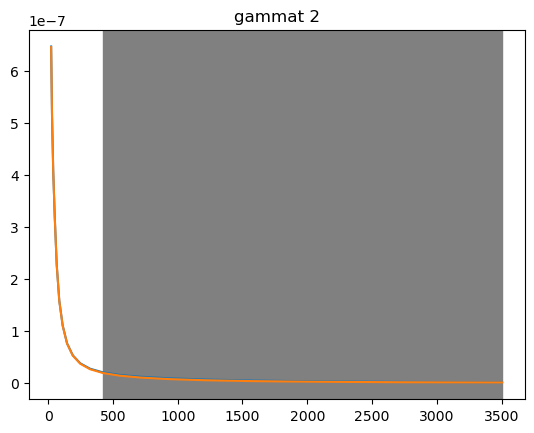

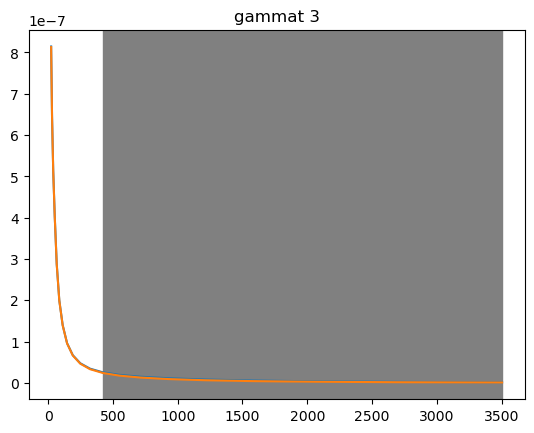

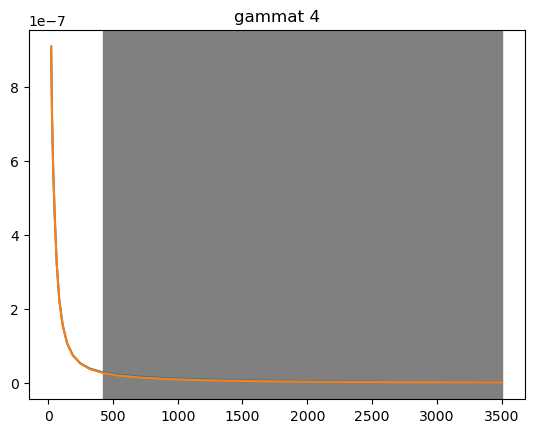

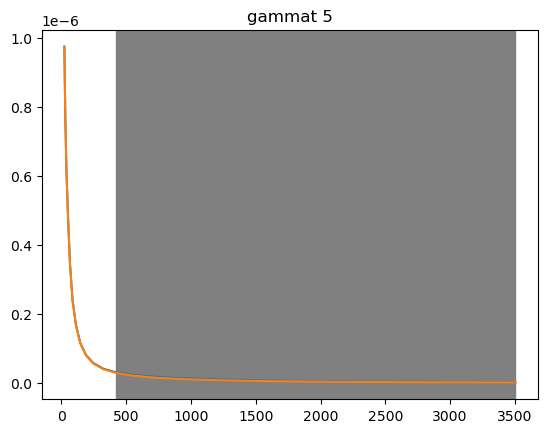

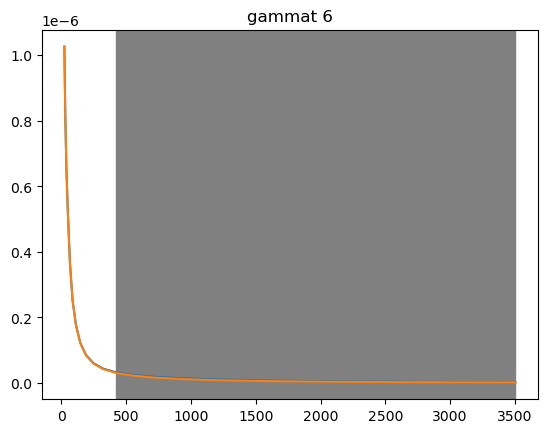

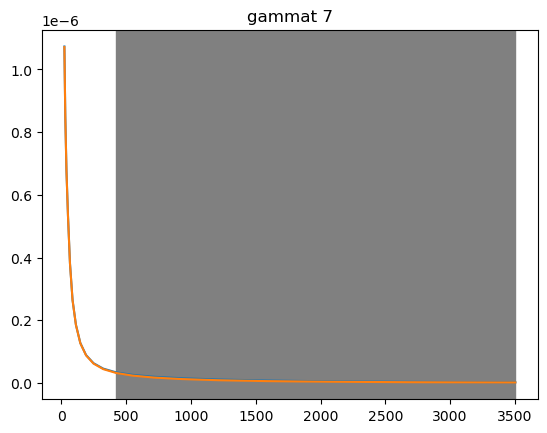

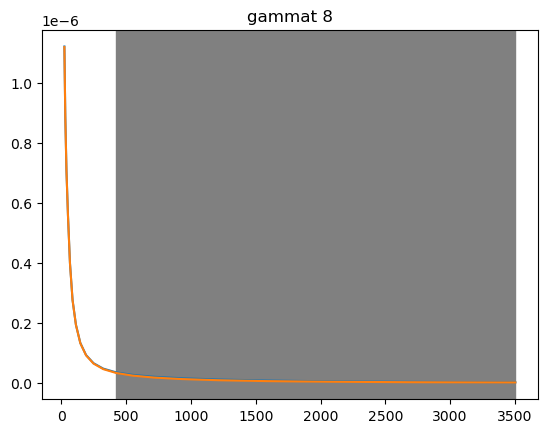

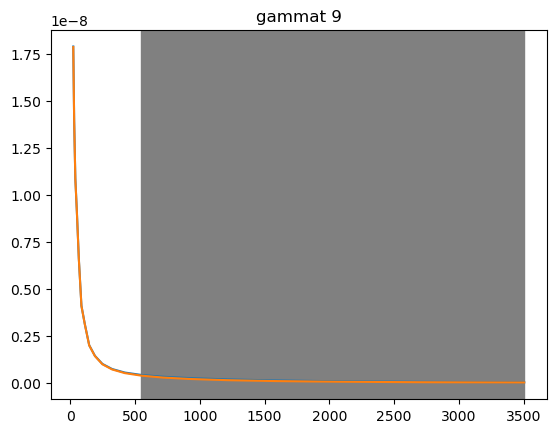

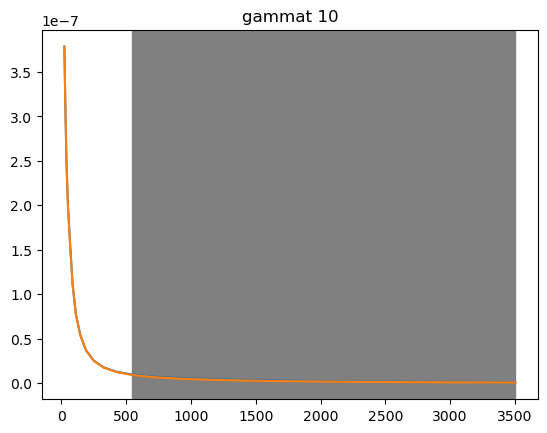

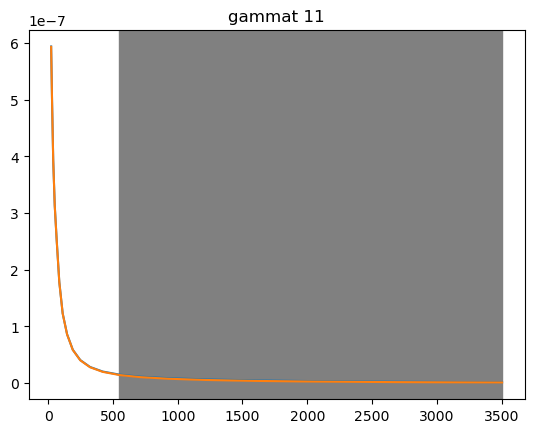

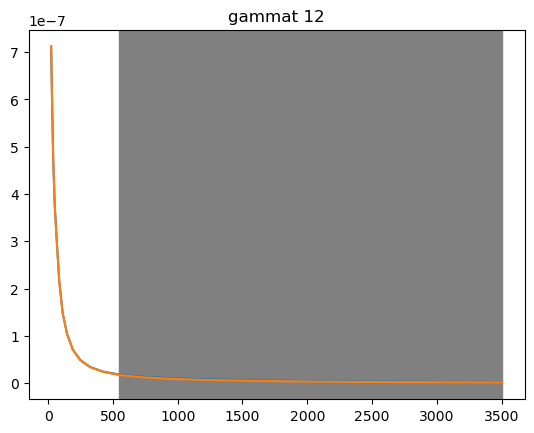

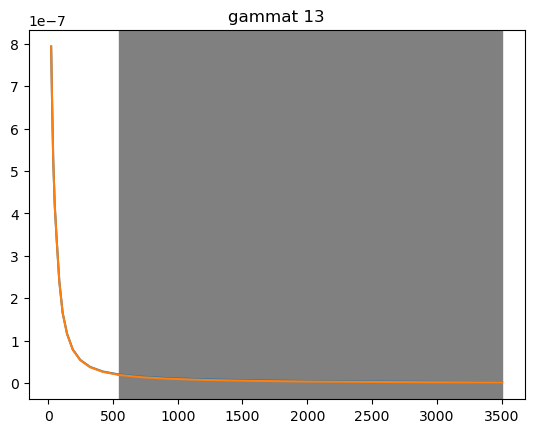

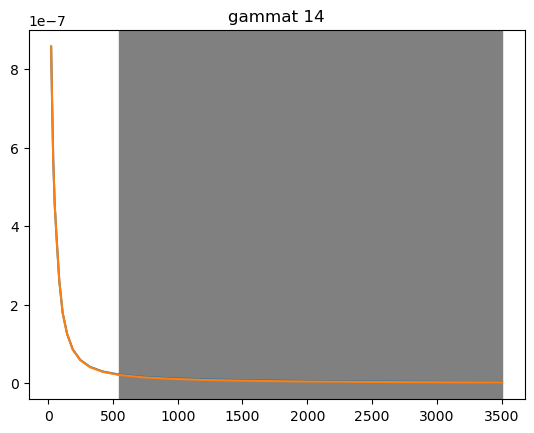

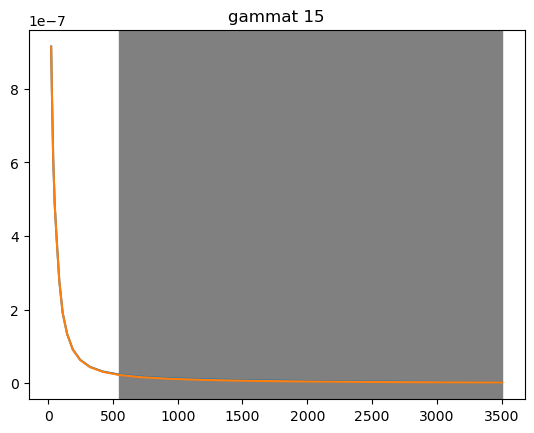

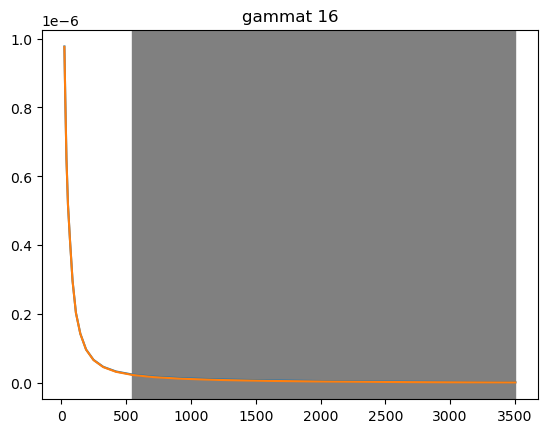

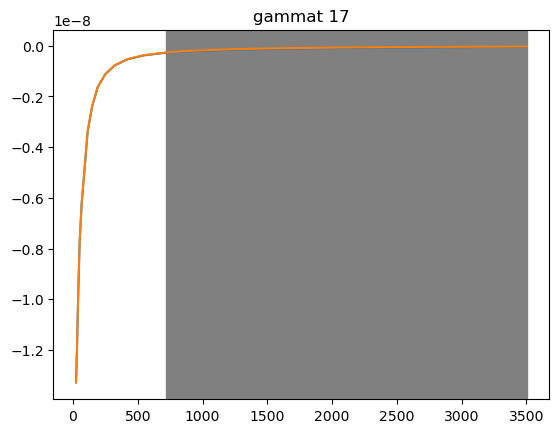

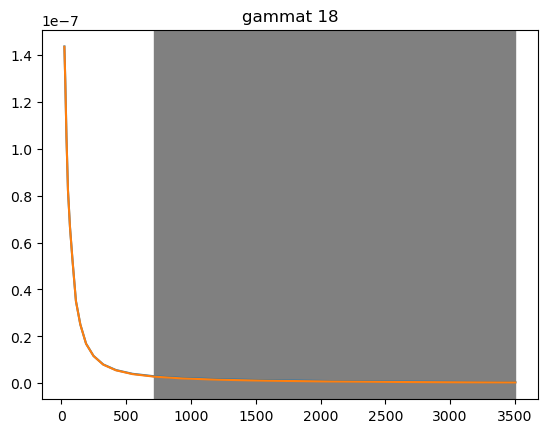

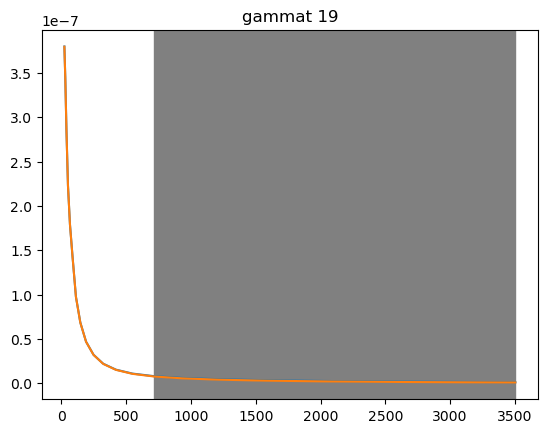

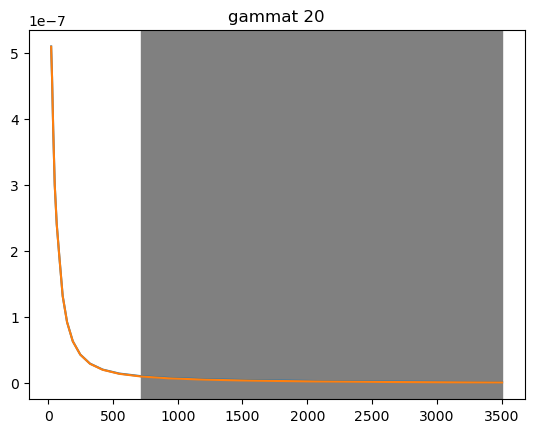

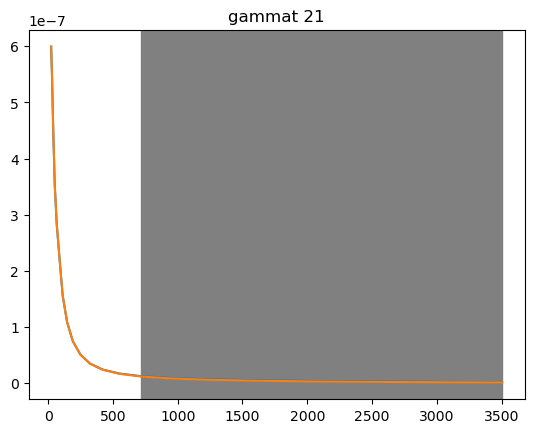

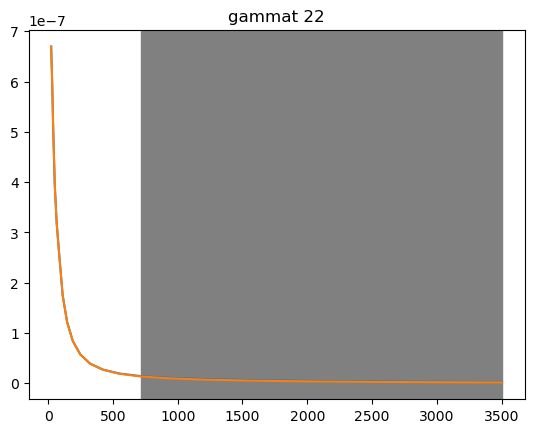

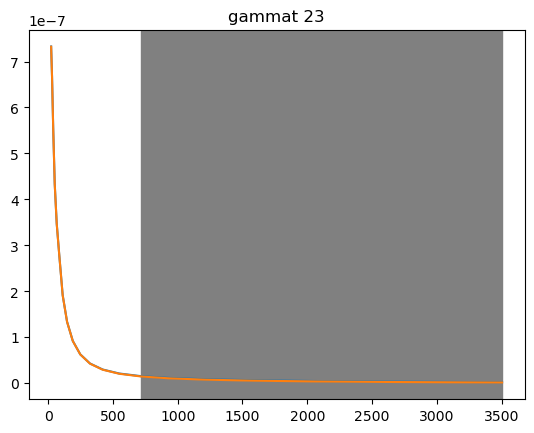

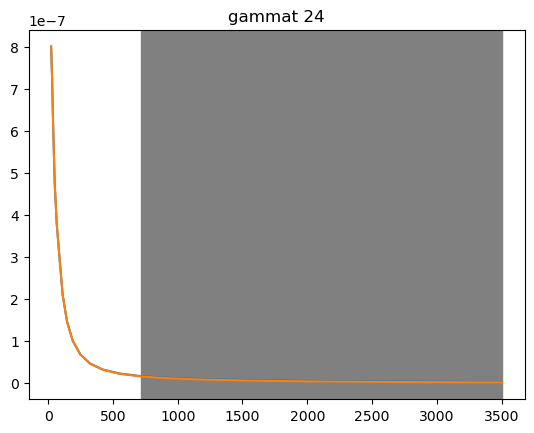

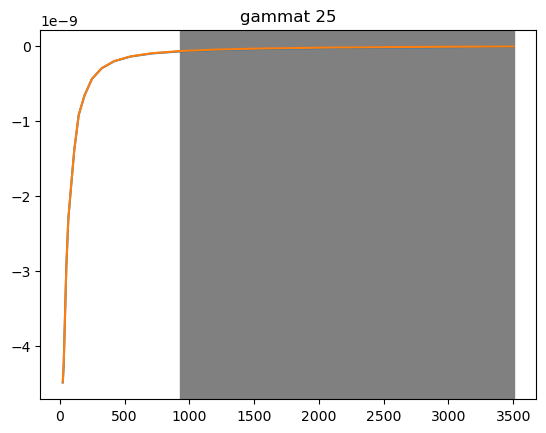

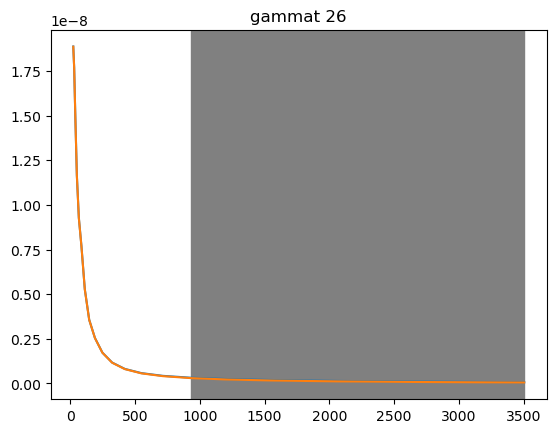

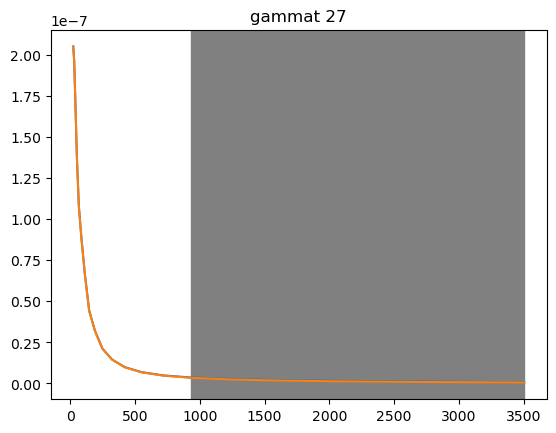

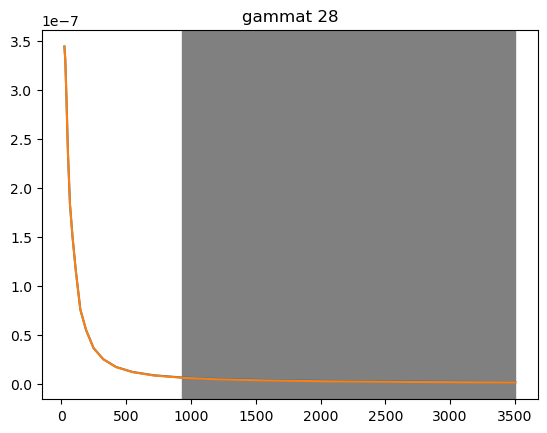

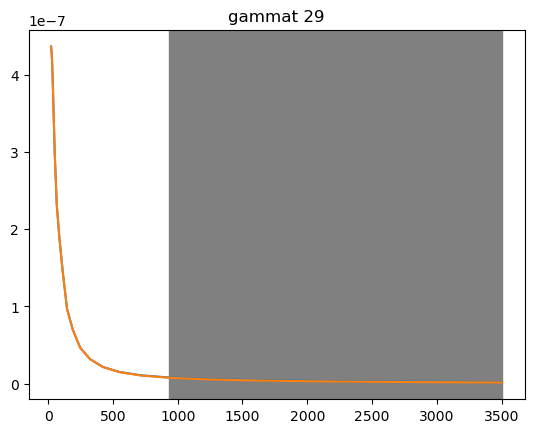

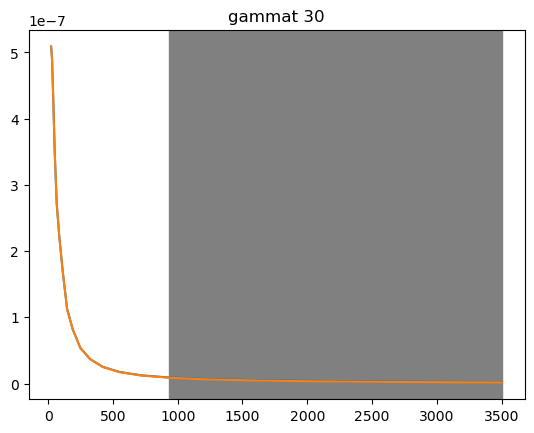

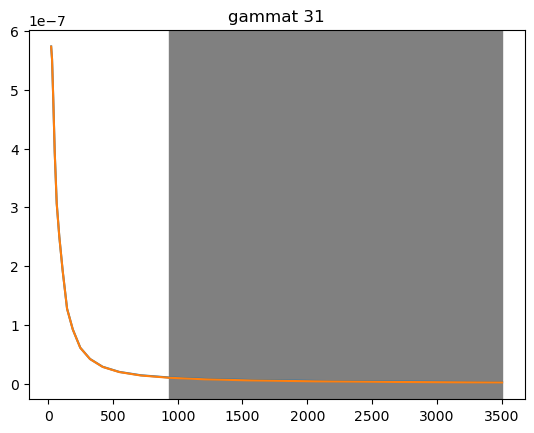

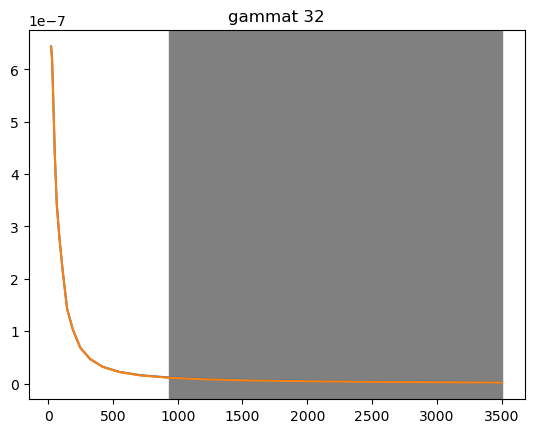

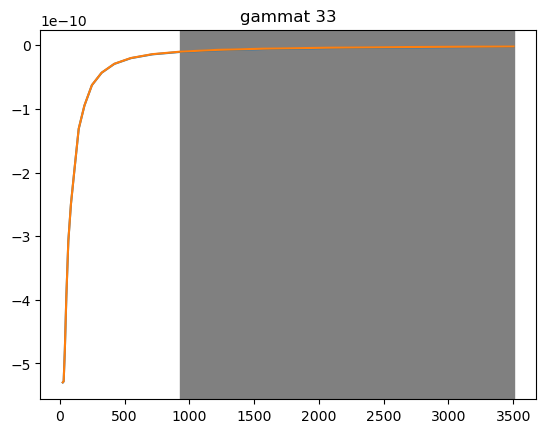

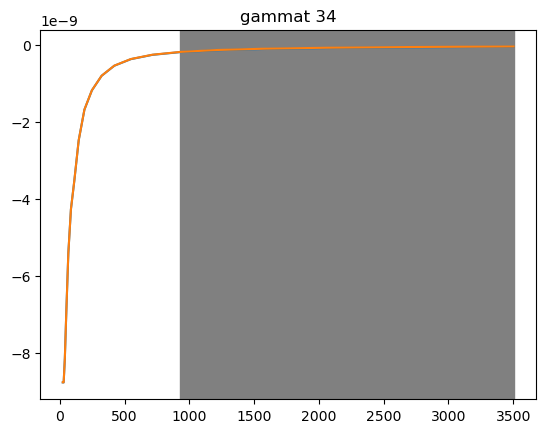

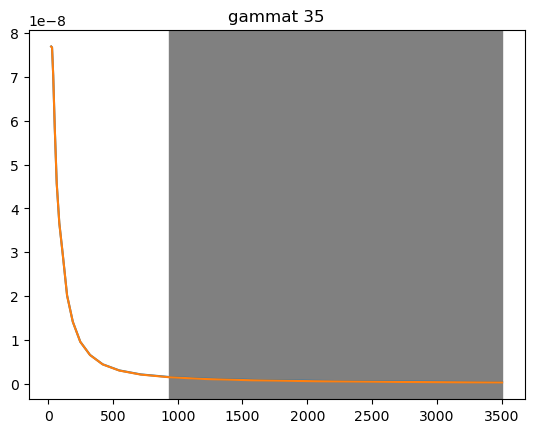

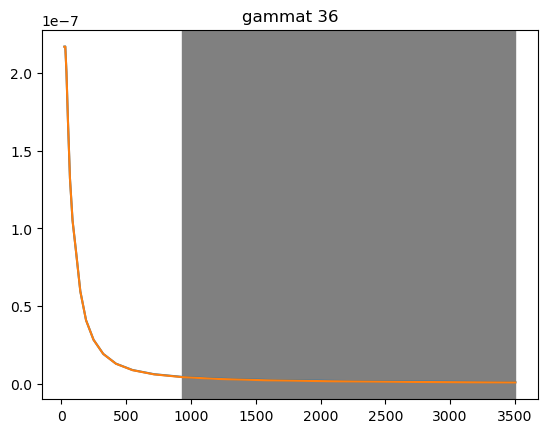

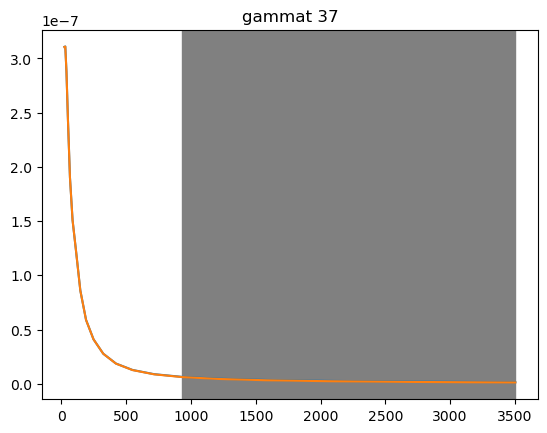

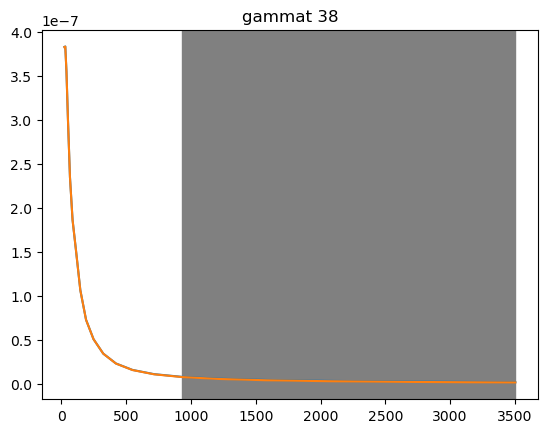

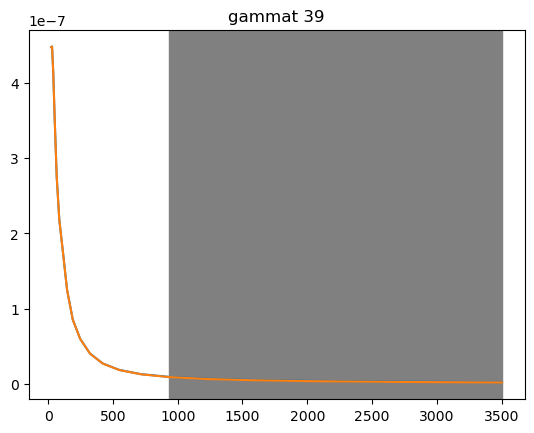

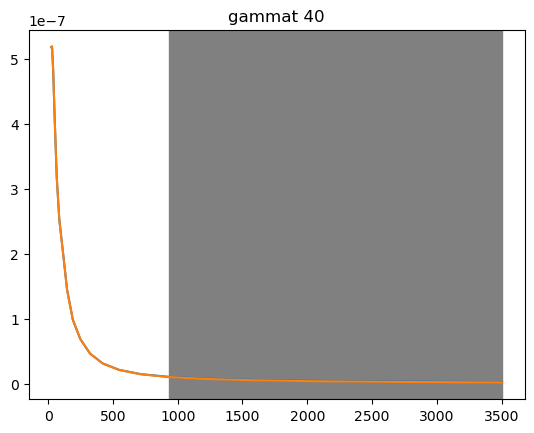

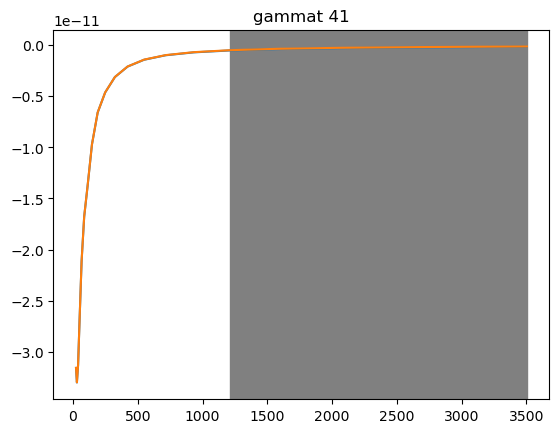

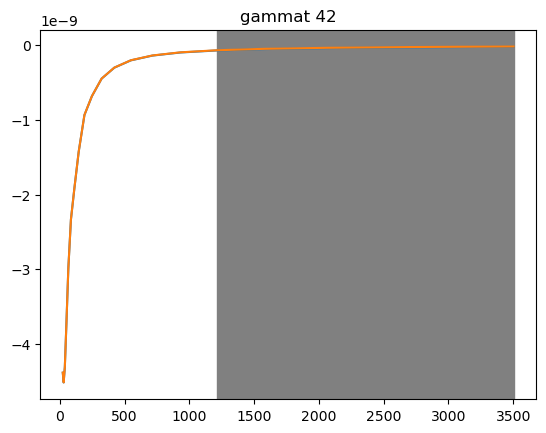

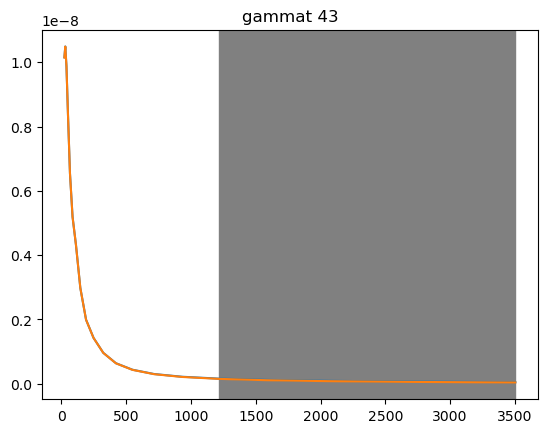

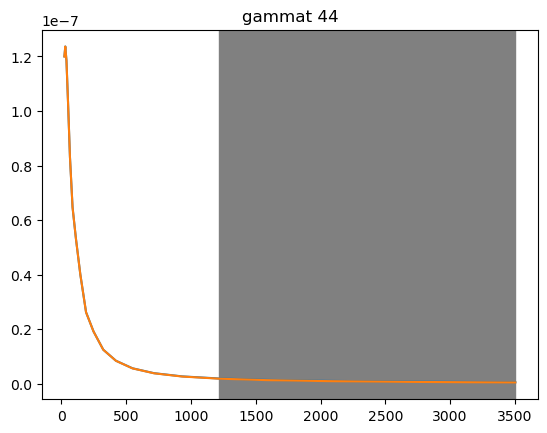

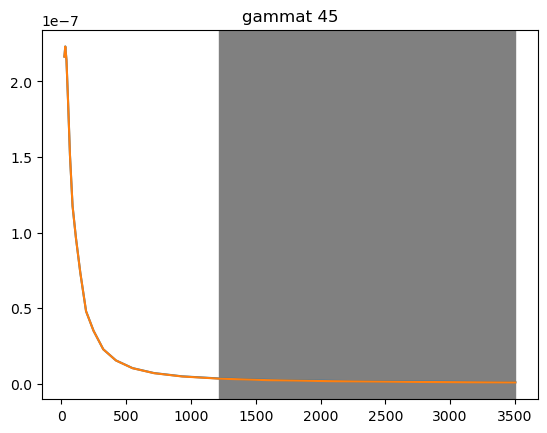

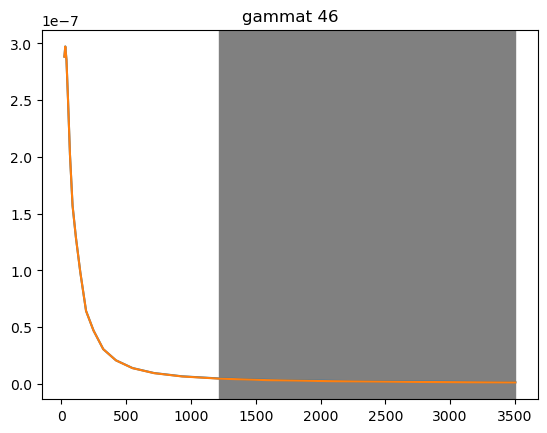

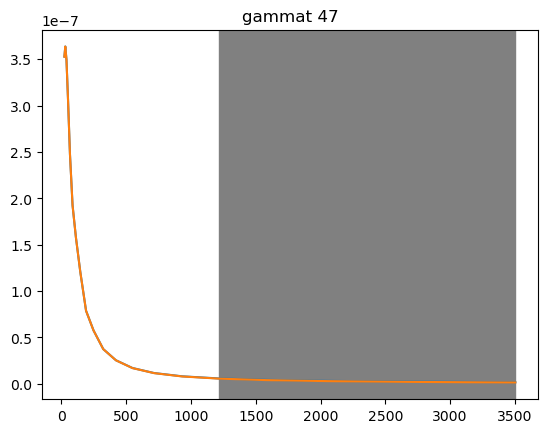

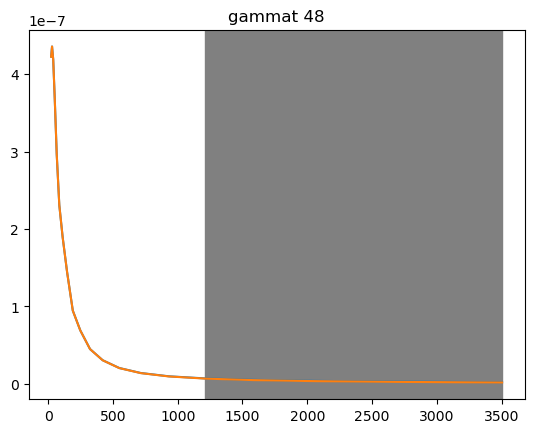

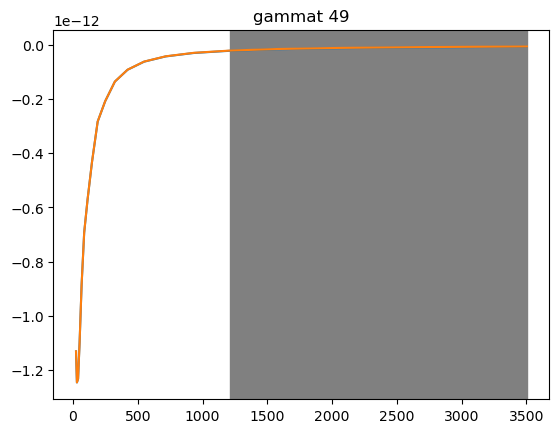

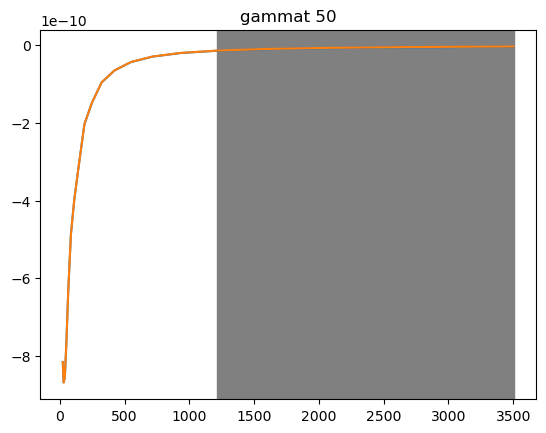

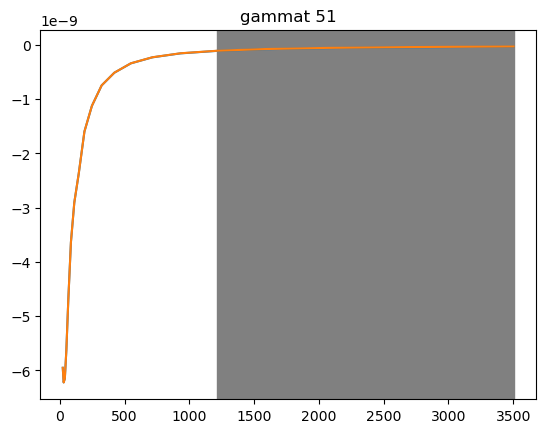

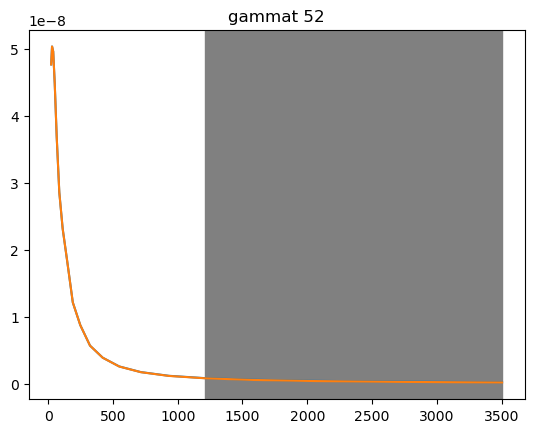

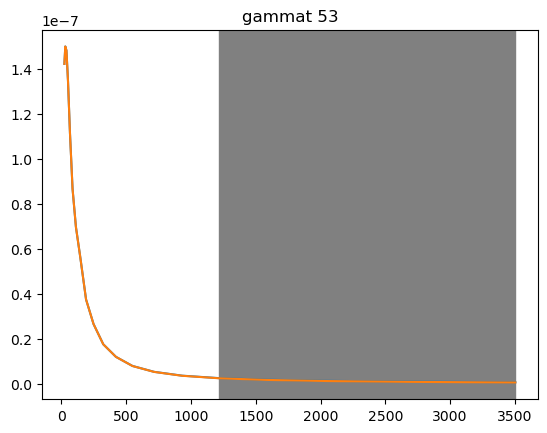

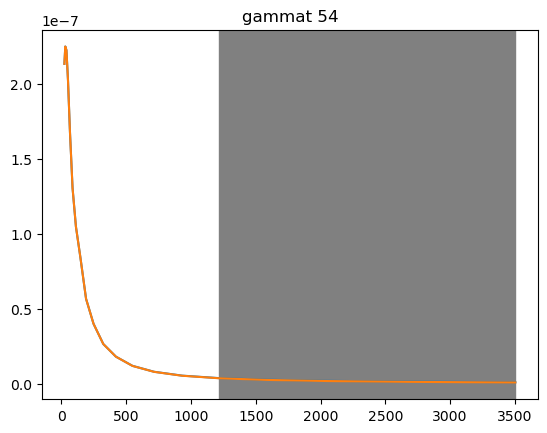

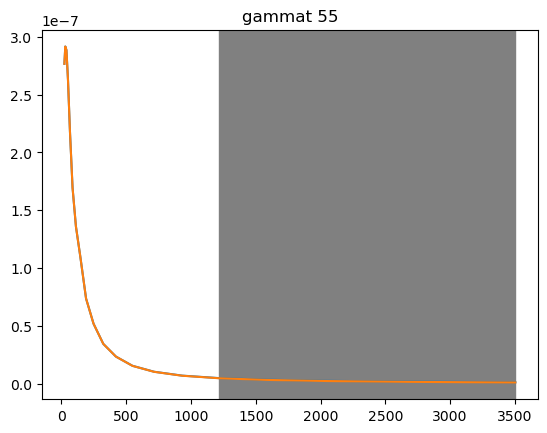

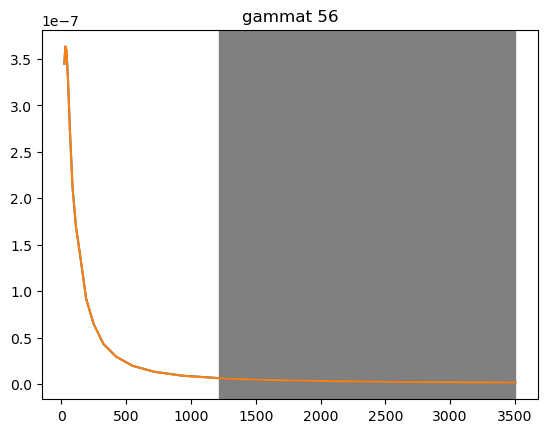

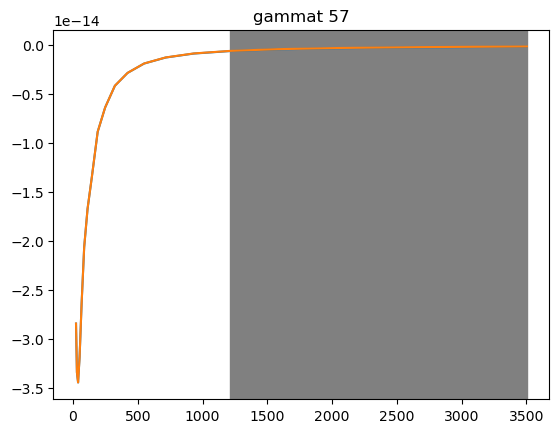

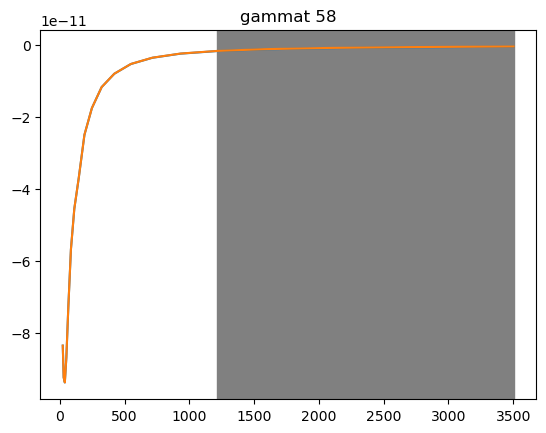

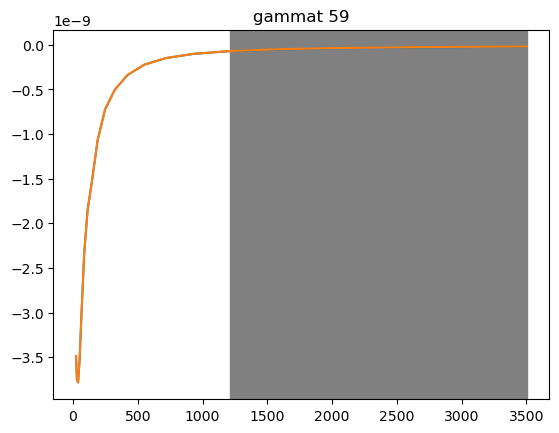

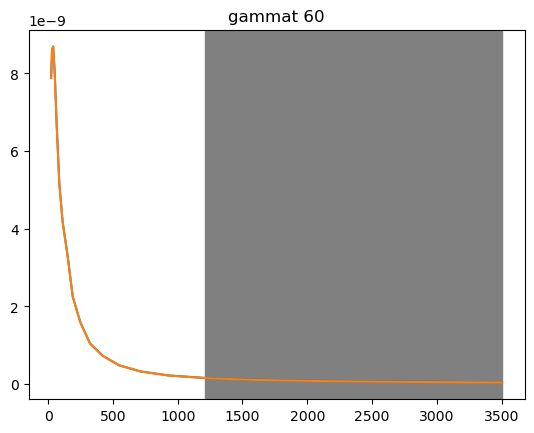

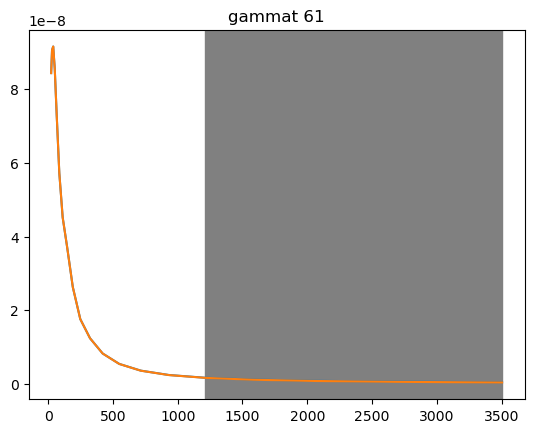

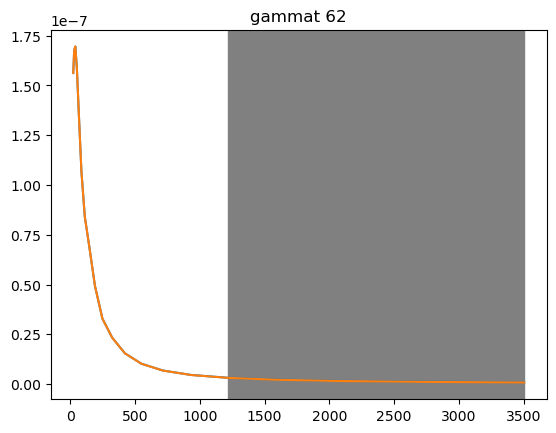

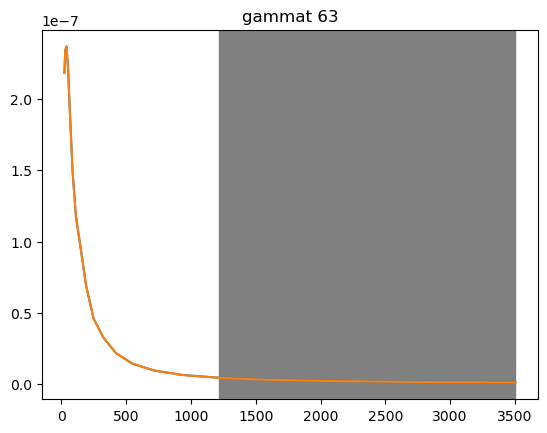

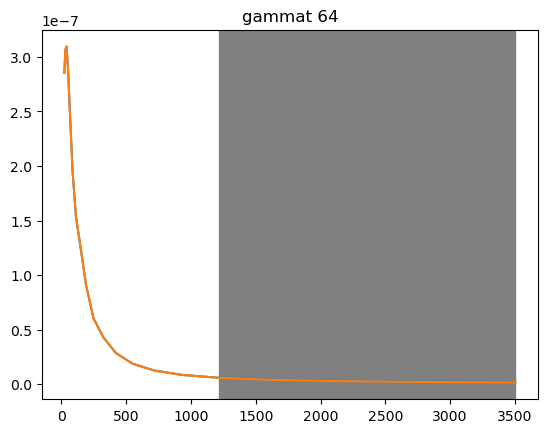

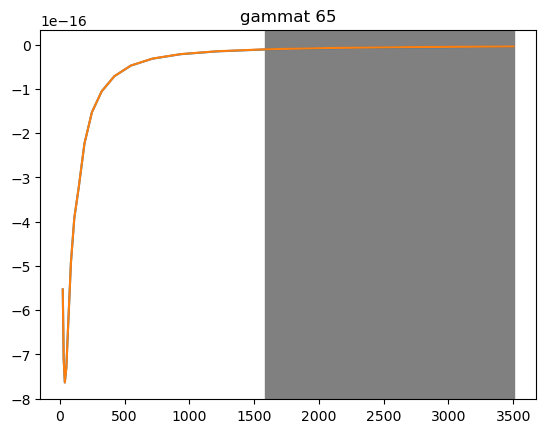

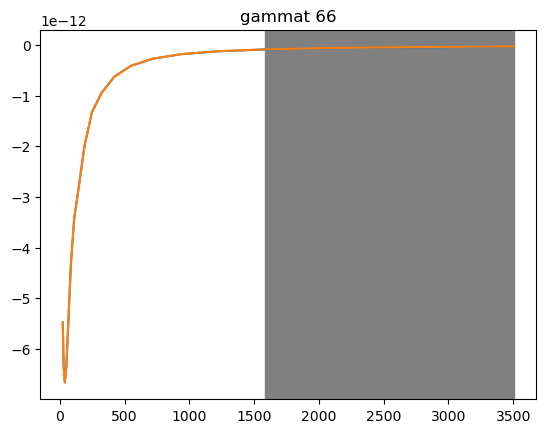

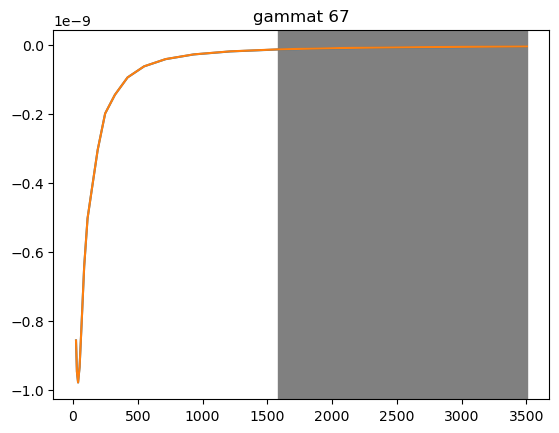

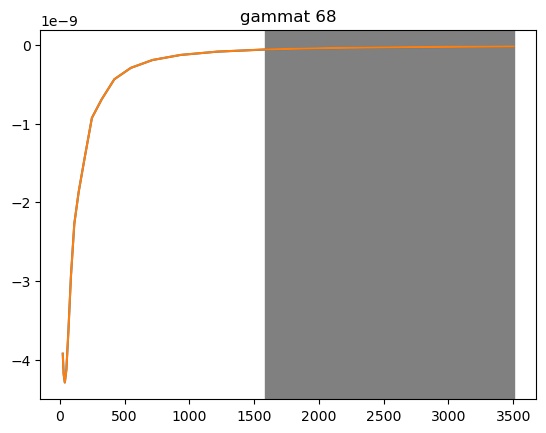

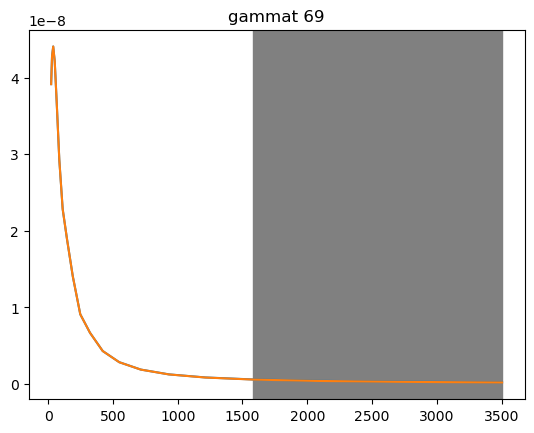

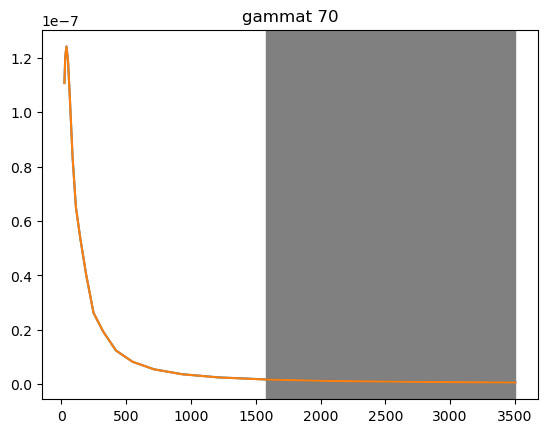

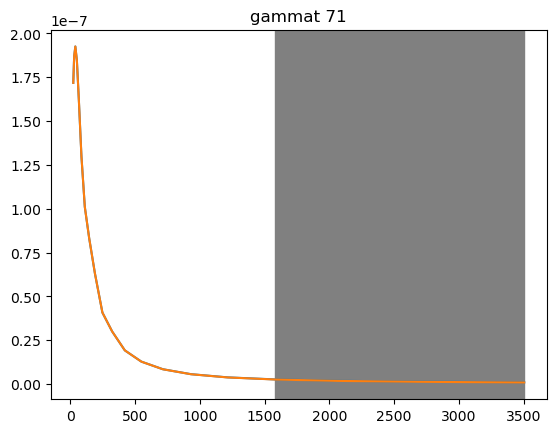

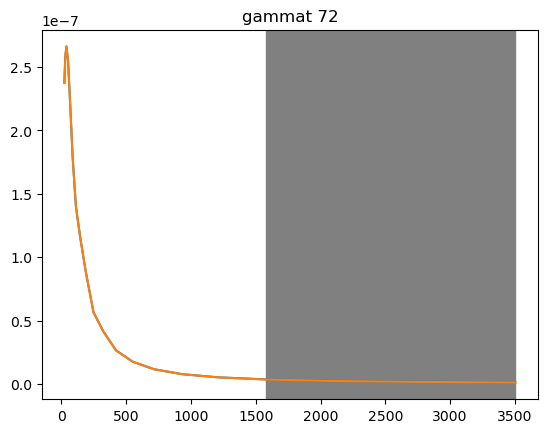

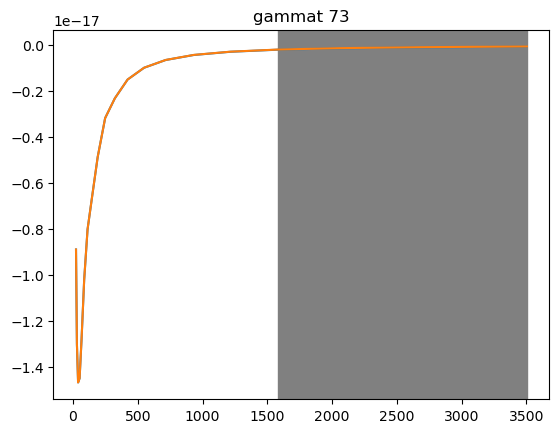

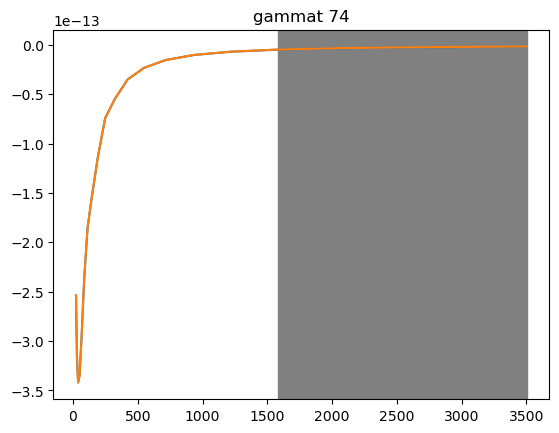

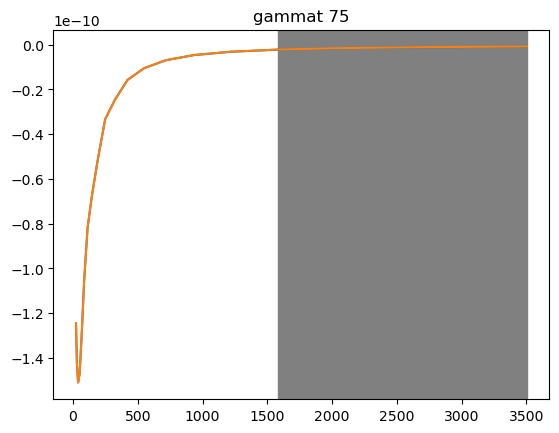

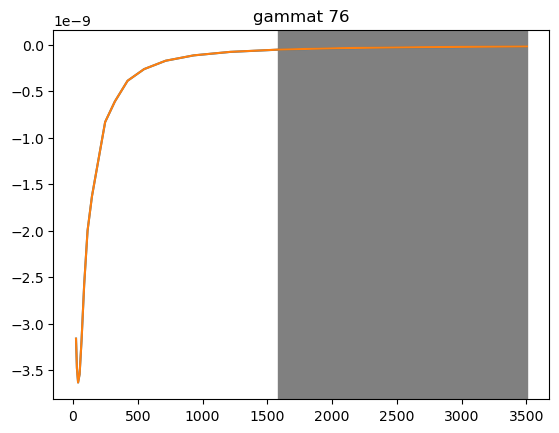

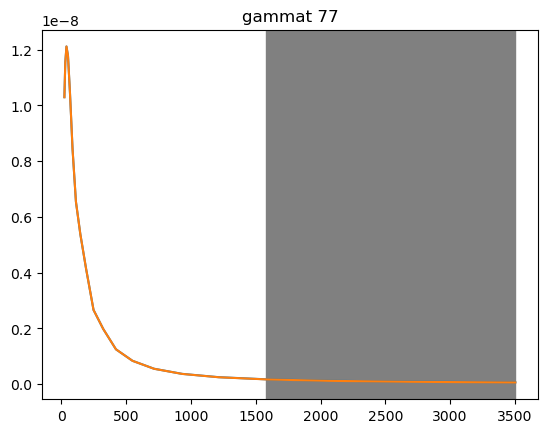

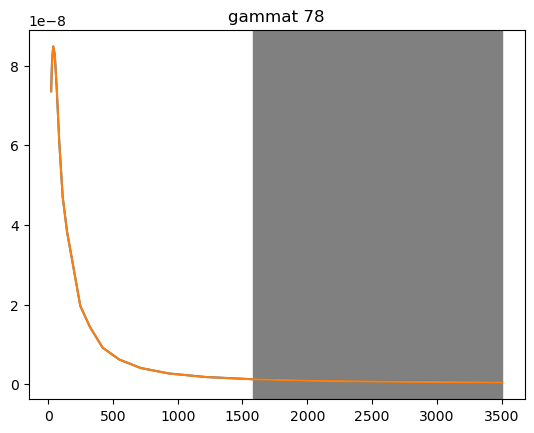

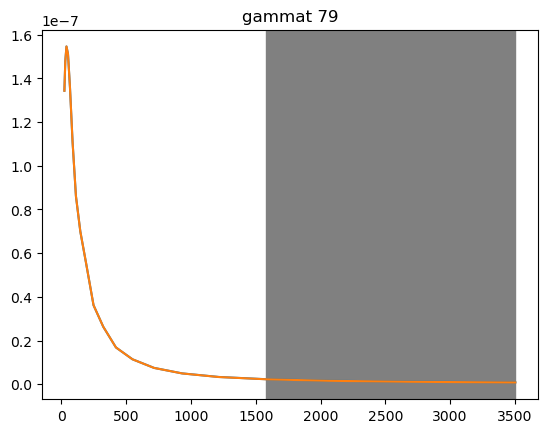

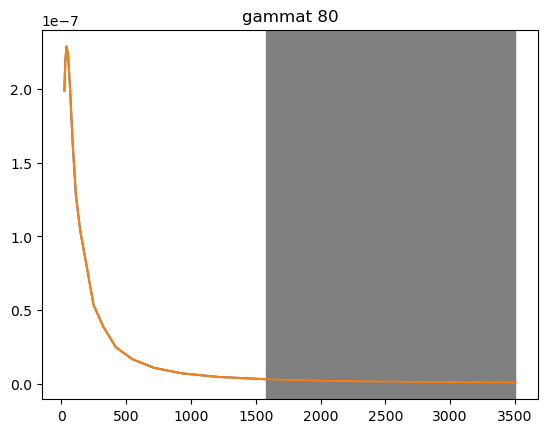

In [ ]:
import matplotlib.pyplot as plt
nlens = 10
nsrcs = 8
ncl = 20

lmin = 20
lmax = 4000
logdl = (np.log(lmax) - np.log(lmin))/ncl
ell = np.zeros(int(ncl))
for i in range(int(ncl)):
    ell[i] = np.exp(np.log(lmin) + (i + 0.5)*logdl)
    
start = int( nsrcs*(nsrcs+1)/2 )
end = int( nsrcs*(nsrcs+1)/2 + nlens*nsrcs )
for i in range(start, end):
    l = i*ncl
    r = (i+1)*ncl
    
    plt.plot(ell, baseline[l:r], label='baseline')
    plt.plot(ell, pollution[l:r], label='pollution')
    mask_seg = mask_shear_full[l:r].astype(bool)
    if sum(~mask_seg)>0:
        plt.axvspan(ell[~mask_seg][0],ell[~mask_seg][-1],color='gray')
    plt.title(f'gammat {i-start+1}')
    plt.show()
    

In [5]:
mask = mask_shear_full

ncl = 20

dv_fid = np.loadtxt('./chains/roman_baseline_evaluate/roman.modelvector')[:,1]
dv_pol = np.loadtxt('./chains/roman_pollution_evaluate/roman.modelvector')[:,1]
cov_raw = np.loadtxt('./data/cov_roman_fourier')

Lencov = int(ncl*(nsrcs*(nsrcs+1)/2 + nsrcs*nlens + nlens))
cov = np.zeros((Lencov, Lencov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i,0])
    jj = int(cov_raw[i,1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

starts = [0, int(nsrcs*(nsrcs+1)/2*ncl), int((nsrcs*(nsrcs+1)/2 + nsrcs*nlens)*ncl), int((nsrcs*(nsrcs+1)/2 + nsrcs*nlens + nlens)*ncl)]
for i in range(0,1):
    seg_delta = dv_fid[starts[i] : starts[i+1]] - dv_pol[starts[i] : starts[i+1]]
    seg_cov   = cov[starts[i] : starts[i+1], :][:, starts[i] : starts[i+1]]
    seg_mask  = mask[starts[i] : starts[i+1]].astype(bool)
    chi2 = seg_delta[seg_mask]@np.linalg.pinv(seg_cov[seg_mask,:][:,seg_mask])@seg_delta[seg_mask]
    print(f'chi2 = {chi2}')

chi2 = 0.3003776553352187


In [2]:
nlen = len(mask_full)
out = np.zeros((nlen,2))
out[:,0] = np.arange(nlen)
out[:,1] = mask_full
print(f'check the number {np.sum(mask_full)}/{len(mask_full)} for this mask')
np.savetxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_Y3.mask', out)

check the number 1614.0/3240 for this mask


### this is for len=source

In [1]:
import numpy as np
import scipy

nsrcs = 8
nlens = 8
ntheta = 20
ggl_exclude= [(6, 0), (7, 0), (7, 1)]
ndv = (nsrcs*(nsrcs+1)+nsrcs*nlens+nlens-len(ggl_exclude))*ntheta

baseline  = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_les_evaluate/roman_les.modelvector')[:,1]
                        
pollution = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_les_pollution_evaluate/roman_les_pollution.modelvector')[:,1]
print(f'len of baseline {len(baseline)}; len of polution {len(pollution)}; expected ndv {ndv}')

cov_raw = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/cov_roman_les')
cov = np.zeros((ndv,ndv))
for i in range(len(cov_raw)):
    ii,jj = int(cov_raw[i,0]),int(cov_raw[i,1])
    component = cov_raw[i,8]+cov_raw[i,9]
    cov[ii,jj] = component
    cov[jj,ii] = component

#mask = np.ones(ndv)
mask_full = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_les_full_shear_DESY3_lens.mask')[:,1]
tol = 0.5/20

def probechi2(start,end,probe):
    delta = (pollution - baseline)[start:end]
    mask = mask_full[start:end].astype(bool)
    delta_masked = delta[mask]
    cov_delta = cov[start:end,:][:,start:end]
    cov_delta_masked = cov_delta[mask,:][:,mask]
    invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
    chi2 = delta_masked@invcov_delta_masked@delta_masked
    print(f'chi2 of probe {probe} is {chi2}')
    print(f'{np.sum(mask)}/{len(mask)} points remain for probe {probe}')

ncombo0=0
cnt = 0
for ni in range(nsrcs):
    for nj in range(ni, nsrcs):
        delta = (pollution - baseline)[cnt*ntheta:(cnt+1)*ntheta]
        mask = mask_full[cnt*ntheta:(cnt+1)*ntheta].astype(bool)
        delta_masked = delta[mask]
        cov_delta = cov[cnt*ntheta:(cnt+1)*ntheta,:][:,cnt*ntheta:(cnt+1)*ntheta]
        cov_delta_masked = cov_delta[mask,:][:,mask]
        invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
        chi2 = delta_masked@invcov_delta_masked@delta_masked
        idx_mask=0
        while(chi2>tol):
            mask_full[cnt*ntheta+idx_mask] = 0
            mask = mask_full[cnt*ntheta:(cnt+1)*ntheta].astype(bool)
            delta_masked = delta[mask]
            cov_delta = cov[cnt*ntheta:(cnt+1)*ntheta,:][:,cnt*ntheta:(cnt+1)*ntheta]
            cov_delta_masked = cov_delta[mask,:][:,mask]
            invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
            chi2 = delta_masked@invcov_delta_masked@delta_masked
            idx_mask+=1
        print(f'xi+ ni={ni}, nj={nj}, chi2={chi2}')
        cnt+=1
ncombo1=cnt
probechi2(ncombo0*ntheta, ncombo1*ntheta, 'xi+')
for ni in range(nsrcs):
    for nj in range(ni, nsrcs):
        delta = (pollution - baseline)[cnt*ntheta:(cnt+1)*ntheta]
        mask = mask_full[cnt*ntheta:(cnt+1)*ntheta].astype(bool)
        delta_masked = delta[mask]
        cov_delta = cov[cnt*ntheta:(cnt+1)*ntheta,:][:,cnt*ntheta:(cnt+1)*ntheta]
        cov_delta_masked = cov_delta[mask,:][:,mask]
        invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
        chi2 = delta_masked@invcov_delta_masked@delta_masked
        idx_mask=0
        while(chi2>tol):
            mask_full[cnt*ntheta+idx_mask] = 0
            mask = mask_full[cnt*ntheta:(cnt+1)*ntheta].astype(bool)
            delta_masked = delta[mask]
            cov_delta = cov[cnt*ntheta:(cnt+1)*ntheta,:][:,cnt*ntheta:(cnt+1)*ntheta]
            cov_delta_masked = cov_delta[mask,:][:,mask]
            invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
            chi2 = delta_masked@invcov_delta_masked@delta_masked
            idx_mask+=1
        print(f'xi- ni={ni}, nj={nj}, chi2={chi2}')
        cnt+=1
ncombo2=cnt
probechi2(ncombo1*ntheta, ncombo2*ntheta,'xi-')
for ni in range(nlens):
    for nj in range(nsrcs):
        if (ni, nj) in ggl_exclude:
            continue
        delta = (pollution - baseline)[cnt*ntheta:(cnt+1)*ntheta]
        mask = mask_full[cnt*ntheta:(cnt+1)*ntheta].astype(bool)
        delta_masked = delta[mask]
        cov_delta = cov[cnt*ntheta:(cnt+1)*ntheta,:][:,cnt*ntheta:(cnt+1)*ntheta]
        cov_delta_masked = cov_delta[mask,:][:,mask]
        invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
        chi2 = delta_masked@invcov_delta_masked@delta_masked
        print(f'gammat ni={ni}, nj={nj}, chi2={chi2}')
        cnt+=1
ncombo3=cnt
probechi2(ncombo2*ntheta, ncombo3*ntheta,'gammat')
for ni in range(nlens):
        delta = (pollution - baseline)[cnt*ntheta:(cnt+1)*ntheta]
        mask = mask_full[cnt*ntheta:(cnt+1)*ntheta].astype(bool)
        delta_masked = delta[mask]
        cov_delta = cov[cnt*ntheta:(cnt+1)*ntheta,:][:,cnt*ntheta:(cnt+1)*ntheta]
        cov_delta_masked = cov_delta[mask,:][:,mask]
        invcov_delta_masked = scipy.linalg.inv(cov_delta_masked)
        chi2 = delta_masked@invcov_delta_masked@delta_masked
        print(f'wtheta ni={ni}, nj={ni}, chi2={chi2}')
        cnt+=1
ncombo4=cnt
probechi2(ncombo3*ntheta, ncombo4*ntheta,'wtheta')

len of baseline 2820; len of polution 2820; expected ndv 2820
xi+ ni=0, nj=0, chi2=0.007333205157432783
xi+ ni=0, nj=1, chi2=0.007354149603668271
xi+ ni=0, nj=2, chi2=0.005969882712647521
xi+ ni=0, nj=3, chi2=0.0050880811406296255
xi+ ni=0, nj=4, chi2=0.004388915473840122
xi+ ni=0, nj=5, chi2=0.0037793509231703556
xi+ ni=0, nj=6, chi2=0.00318212526855633
xi+ ni=0, nj=7, chi2=0.002485424397605823
xi+ ni=1, nj=1, chi2=0.01193417323329
xi+ ni=1, nj=2, chi2=0.018108535799891686
xi+ ni=1, nj=3, chi2=0.01751342822230465
xi+ ni=1, nj=4, chi2=0.01685531016864341
xi+ ni=1, nj=5, chi2=0.01586001651207644
xi+ ni=1, nj=6, chi2=0.014412418376042038
xi+ ni=1, nj=7, chi2=0.012136483167720591
xi+ ni=2, nj=2, chi2=0.013914654702199021
xi+ ni=2, nj=3, chi2=0.023768484622344956
xi+ ni=2, nj=4, chi2=0.02282065031204251
xi+ ni=2, nj=5, chi2=0.022219435219581894
xi+ ni=2, nj=6, chi2=0.020749233362198326
xi+ ni=2, nj=7, chi2=0.02316375932161467
xi+ ni=3, nj=3, chi2=0.02046421460739021
xi+ ni=3, nj=4, chi2=0.

In [2]:
nlen = len(mask_full)
out = np.zeros((nlen,2))
out[:,0] = np.arange(nlen)
out[:,1] = mask_full
print(f'check the number {np.sum(mask_full)}/{len(mask_full)} for this mask')
np.savetxt('./data/roman_les_Y3.mask', out)

check the number 1437.0/2820 for this mask


In [1]:
mask = mask_full

dv_fid = np.loadtxt('./chains/roman_baseline_evaluate/roman.modelvector')[:,1]
dv_pol = np.loadtxt('./chains/roman_pollution_evaluate/roman.modelvector')[:,1]
cov_raw = np.loadtxt('./data/cov_roman_fourier')

Lencov = int(ncl*(nsrcs*(nsrcs+1)/2 + nsrcs*nlens + nlens))
cov = np.zeros((Lencov, Lencov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i,0])
    jj = int(cov_raw[i,1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

starts = [0, int(nsrcs*(nsrcs+1)/2*ncl), int((nsrcs*(nsrcs+1)/2 + nsrcs*nlens)*ncl), int((nsrcs*(nsrcs+1)/2 + nsrcs*nlens + nlens)*ncl)]
for i in range(0,1):
    seg_delta = dv_fid[starts[i] : starts[i+1]] - dv_pol[starts[i] : starts[i+1]]
    seg_cov   = cov[starts[i] : starts[i+1], :][:, starts[i] : starts[i+1]]
    seg_mask  = mask[starts[i] : starts[i+1]].astype(bool)
    chi2 = seg_delta[seg_mask]@np.linalg.pinv(seg_cov[seg_mask,:][:,seg_mask])@seg_delta[seg_mask]
    print(f'chi2 = {chi2}')

NameError: name 'mask_full' is not defined